# Paramétrage de l'environnement de travail et import des packages

In [2]:
import sys
from pathlib import Path

In [3]:
ROOT = Path.cwd().parents[0]

RAW_DATA = ROOT / "01_data" / "01_raw"
PROCESSED_DATA = ROOT / "01_data" / "02_processed"

%load_ext autoreload
%autoreload 2
sys.path.append(str(ROOT / "03_fonctions"))

In [4]:
import pandas as pd
import numpy as np
from fonctions_perso.data_manipulation import multi_astype

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector

from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform
from sklearn.calibration import CalibratedClassifierCV

from fonctions_perso.machine_learning import IsolationForestCustom
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import seaborn as sns
import matplotlib.pyplot as plt
from fonctions_perso.machine_learning import ThresholdCostOptimizer, BinaryMetricsSimple, graphique_courbe_pr, graphique_courbe_calibration

from sklearn import set_config
set_config(transform_output="pandas")

import joblib


# La base de données

In [5]:
data_fraud = pd.read_parquet(PROCESSED_DATA / "data_fraud_eda_processed.parquet").reset_index(drop = True)

In [6]:
multi_astype(
    data_fraud,
    ["type_magasin","etat_client","heure_transaction"],
    "string"
)

type_magasin: object → string
etat_client: object → string
heure_transaction: int32 → string

Succès: 3/3


**Informations globales**

In [7]:
data_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 19 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   nom_magasin                object 
 1   type_magasin               string 
 2   montant_transaction        float64
 3   ville_client               object 
 4   etat_client                string 
 5   latitude_domicile_client   float64
 6   longitude_domicile_client  float64
 7   population_ville_client    int64  
 8   profession_client          object 
 9   numero_transaction         object 
 10  latitude_magasin           float64
 11  longitude_magasin          float64
 12  target                     int64  
 13  annee_transaction          int32  
 14  mois_transaction           object 
 15  jour_transaction           object 
 16  heure_transaction          string 
 17  distance_domicile_magasin  float64
 18  age_client                 int32  
dtypes: float64(6), int32(2), int64(2), object(

**Statistiques descriptives**

In [8]:
data_fraud.describe()

,montant_transaction,latitude_domicile_client,longitude_domicile_client,population_ville_client,latitude_magasin,longitude_magasin,target,annee_transaction,distance_domicile_magasin,age_client
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,7.006357e+01,3.853931e+01,-9.022783e+01,8.864367e+04,3.853898e+01,-9.022794e+01,5.210015e-03,2.019501e+03,7.611183e+01,4.621138e+01
std,1.592540e+02,5.071470e+00,1.374789e+01,3.014876e+05,5.105604e+00,1.375969e+01,7.199217e-02,4.999996e-01,2.911701e+01,1.739545e+01
min,1.000000e+00,2.002710e+01,-1.656723e+02,2.300000e+01,1.902742e+01,-1.666716e+02,0.000000e+00,2.019000e+03,2.225455e-02,1.400000e+01
25%,9.640000e+00,3.466890e+01,-9.679800e+01,7.410000e+02,3.474012e+01,-9.689944e+01,0.000000e+00,2.019000e+03,5.532016e+01,3.300000e+01
50%,4.745000e+01,3.935430e+01,-8.747690e+01,2.443000e+03,3.936890e+01,-8.744069e+01,0.000000e+00,2.020000e+03,7.821649e+01,4.400000e+01
75%,8.310000e+01,4.194040e+01,-8.015800e+01,2.032800e+04,4.195626e+01,-8.024511e+01,0.000000e+00,2.020000e+03,9.850960e+01,5.700000e+01
max,2.894890e+04,6.669330e+01,-6.795030e+01,2.906700e+06,6.751027e+01,-6.695090e+01,1.000000e+00,2.020000e+03,1.521174e+02,9.600000e+01


**Aperçu rapide des données**

In [9]:
data_fraud.head()

,nom_magasin,type_magasin,montant_transaction,ville_client,etat_client,latitude_domicile_client,longitude_domicile_client,population_ville_client,profession_client,numero_transaction,latitude_magasin,longitude_magasin,target,annee_transaction,mois_transaction,jour_transaction,heure_transaction,distance_domicile_magasin,age_client
0,Kirlin and Sons,personal_care,2.86,Columbia,SC,33.9659,-80.9355,333497,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,33.986391,-81.200714,0,2020,June,Sunday,12,24.561496,52
1,Sporer-Keebler,personal_care,29.84,Altonah,UT,40.3207,-110.4360,302,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,39.450498,-109.960431,0,2020,June,Sunday,12,104.925237,30
2,"Swaniawski, Nitzsche and Welch",health_fitness,41.28,Bellmore,NY,40.6729,-73.5365,34496,"Librarian, public",c81755dbbbea9d5c77f094348a7579be,40.495810,-74.196111,0,2020,June,Sunday,12,59.080159,50
3,Haley Group,misc_pos,60.05,Titusville,FL,28.5697,-80.8191,54767,Set designer,2159175b9efe66dc301f149d3d5abf8c,28.812398,-80.883061,0,2020,June,Sunday,12,27.698606,33
4,Johnston-Casper,travel,3.19,Falmouth,MI,44.2529,-85.0170,1126,Furniture designer,57ff021bd3f328f8738bb535c302a31b,44.959148,-85.884734,0,2020,June,Sunday,12,104.335250,65


# Modèle de Machine Learning

**Construction de l'échantillon '2019' et 'test'**

In [10]:
variables_a_retirer = ["target","nom_magasin","ville_client","profession_client","numero_transaction",
                       "annee_transaction","latitude_domicile_client","longitude_domicile_client",
                       "latitude_magasin","longitude_magasin","mois_transaction","jour_transaction"]


x_2019 = data_fraud[data_fraud["annee_transaction"]==2019].drop(variables_a_retirer, axis=1)
y_2019 = data_fraud[data_fraud["annee_transaction"]==2019]["target"]

x_test = data_fraud[data_fraud["annee_transaction"]==2020].drop(variables_a_retirer, axis=1)
y_test = data_fraud[data_fraud["annee_transaction"]==2020]["target"]

**Construction de l'échantillon 'train' et 'validation'**

In [11]:
x_train, x_validation, y_train, y_validation = train_test_split(
    x_2019, y_2019,
    test_size=0.20,          
    random_state=1,       
    stratify=y_2019                   
)

**Création de la pipeline**

In [12]:
# Preprocessing
    # -- Encodage des variables catégorielles 
var_cat_pipe = Pipeline([
    ("one_hot_encoder", OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore'))
])

    # -- Isolation Forest sur les données et création de la variable "if_score"
all_var_pipe = Pipeline([
    ("isolation_forest", IsolationForestCustom(
        n_estimators=100,        
        max_samples="auto",      
        contamination="auto",    
        max_features=1.0,        
        bootstrap=False,         
        n_jobs=-1,               
        random_state=1,         
        verbose=0,               
        warm_start=False         
    ))
])

    # -- Standardisation des données 
num_pipe = Pipeline([
    ("scaler", StandardScaler())
])


# XGBoost (Objectif : Stabilité)
    # -- Modèle de base
xgb = XGBClassifier(
    scale_pos_weight=200, # 0.995/0.005
    random_state=1,
    n_jobs=-1
)

    # -- Préparation des hyperparamètres à tuner
hyperparametres = {
    "model__n_estimators": randint(50, 200),
    "model__max_depth": randint(3, 6),
    
        # --- Apprentissage lent (0.01 - 0.05)
    "model__learning_rate": loguniform(0.01, 0.05),
    
        # --- Bagging et Feature sampling forts
    "model__subsample": uniform(0.5, 0.3),        
    "model__colsample_bytree": uniform(0.5, 0.3), 
    
        # --- Régularisation forte sur les feuilles (min_child_weight)
    "model__min_child_weight": randint(5, 10),
    
        # --- Réduction de perte minimale pour splitter (Gamma)
    "model__gamma": loguniform(0.01, 0.5), 
    
        # --- Régularisation L1 et L2 (Forte)
    "model__reg_alpha": loguniform(0.1, 1.0),
    "model__reg_lambda": loguniform(1.0, 10.0)
}

In [13]:
# Assemblage 
preprocessing_1 = ColumnTransformer([
    ("one_hot_encoding", var_cat_pipe, make_column_selector(dtype_exclude=np.number))
], remainder="passthrough")

preprocessing_2 = ColumnTransformer([
    ("scaler", num_pipe, make_column_selector(dtype_include=np.number))
], remainder="passthrough")

pipeline_complete = Pipeline([
    ("ohe", preprocessing_1),
    ("isolation_forest", all_var_pipe),
    ("scaler", preprocessing_2),
    ("model", xgb)
])

In [14]:
# Tuning des hyperparamètres
recherche = RandomizedSearchCV(
    estimator = pipeline_complete,
    param_distributions = hyperparametres,
    n_iter = 6,
    scoring = "neg_brier_score",
    cv = 3,  
    return_train_score = True,
    refit = True,
    random_state = 1,
    n_jobs = -1,
    error_score = "raise",
)

_ = recherche.fit(x_train, y_train)
modele = recherche.best_estimator_

In [15]:
# Calibration des probabilités
model_propre = CalibratedClassifierCV(
    estimator = modele,  
    method = 'isotonic',       
    cv = 5                    
)

_ = model_propre.fit(x_train, y_train)

**Recherche du seuil de probabilité optimal à partir de l'échantillon 'validation'**

In [16]:
# Entrainement (Echantillon validation)
y_validation_proba = model_propre.predict_proba(x_validation)[:,1]

<Axes: title={'center': 'Répartition des probabilités (Echantillon validation)'}, xlabel='Probabilités', ylabel='Nombre'>

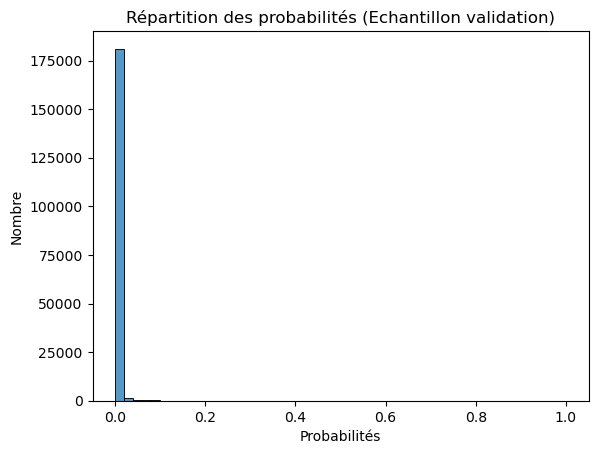

In [17]:
# Répartition des probabilités (Echantillon validation)
df_y_validation_proba = pd.DataFrame(y_validation_proba)
df_y_validation_proba = df_y_validation_proba.rename(columns={0:"proba"})

plt.title("Répartition des probabilités (Echantillon validation)")
plt.xlabel("Probabilités")
plt.ylabel("Nombre")

sns.histplot(
    df_y_validation_proba,
    x="proba",
    bins=50
)

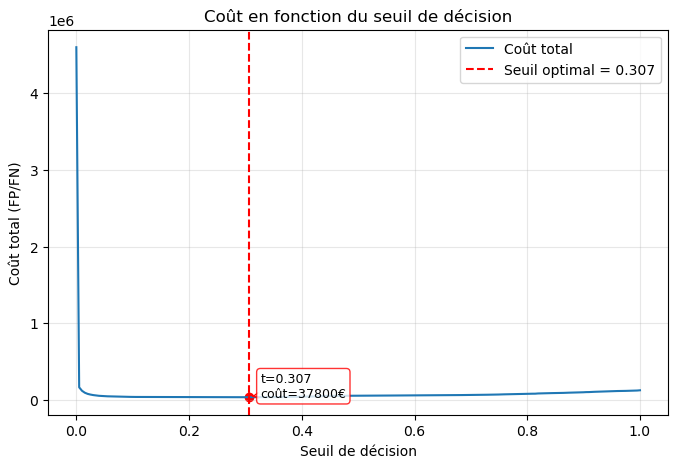

Meilleur seuil : 0.307 | Coût minimal : 37800.00€


In [18]:
# Recherche du seuil permettant de minimiser les couts à partir de l'échantillon "validation"
cost_optimizer = ThresholdCostOptimizer(cost_fp=25, cost_fn=125, n_thresholds=200)

cost_optimizer.fit(y_validation, y_validation_proba)

cost_optimizer.plot_cost_curve()

**Entrainement du modèle sur l'échantillon 'train' et 'test'**

In [19]:
# Train
train_proba = model_propre.predict_proba(x_train)[:,1]
train_pred = (train_proba >= cost_optimizer.get_best_threshold()).astype(int)

# Test
test_proba = model_propre.predict_proba(x_test)[:,1]
test_pred = (test_proba >= cost_optimizer.get_best_threshold()).astype(int)

**Sauvegarde du modèle**

In [20]:
# XGBoost calibré
joblib.dump(model_propre, ROOT / "04_model" / "fraud_detection_model_xgboost.joblib") 

# XGBoost non calibré
joblib.dump(modele, ROOT / "04_model" / "fraud_detection_xgb_pas_calibre.joblib")     

['c:\\Users\\user\\Desktop\\data_science_documents\\data_science_projets_perso\\projet_fraud_detection\\fraud-detection\\04_model\\fraud_detection_xgb_pas_calibre.joblib']

**Sauvegarde de x_test**

In [21]:
x_test.to_parquet(PROCESSED_DATA / "x_test_for_shap.parquet")

# Analyse des performances du modèle

In [22]:
performances_modele = BinaryMetricsSimple(
    y_test, test_pred, test_proba
)

**Métriques**

In [23]:
performances_modele.get_metrics_df() # Métriques principales

,Metrique,Valeur
0,accuracy,0.9970
1,precision,0.6632
2,recall,0.7691
3,f1,0.7122
4,mcc,0.7127
5,roc_auc,0.9933
6,brier_score,0.0020
7,average_precision,0.7644


In [24]:
performances_modele.print_confusion_matrix() # Matrice de confusion

MATRICE DE CONFUSION
                      Prédit Négatif | Prédit Positif
Réel Négatif              921382 |           1731
Réel Positif                1023 |           3408


**Courbe Précision-Rappel**

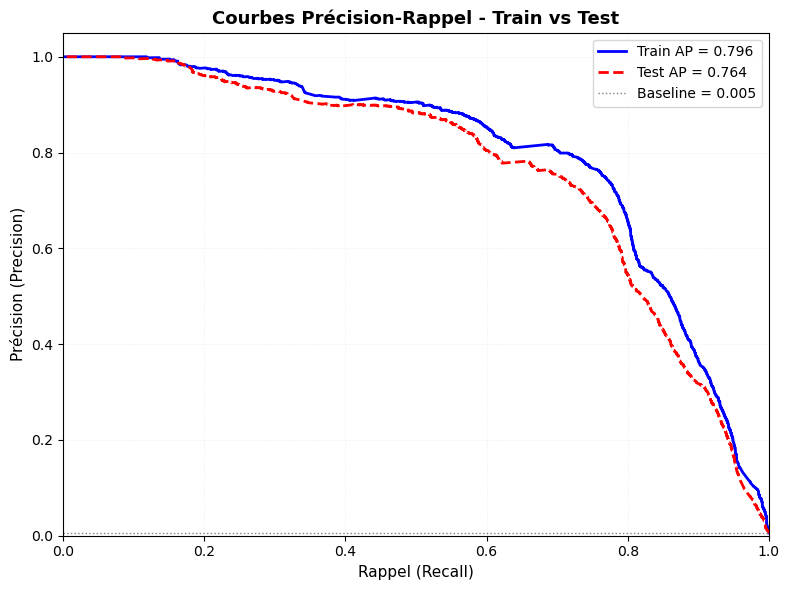


RÉSULTATS PRÉCISION-RAPPEL
AP Train     : 0.7959
AP Test      : 0.7644
Écart        : 0.0315
Baseline     : 0.0048
✓ Écart acceptable
Lift vs baseline : 160.01x


In [25]:
graphique_courbe_pr(
    y_train, train_proba,
    y_test, test_proba
)

**Courbe de calibration**

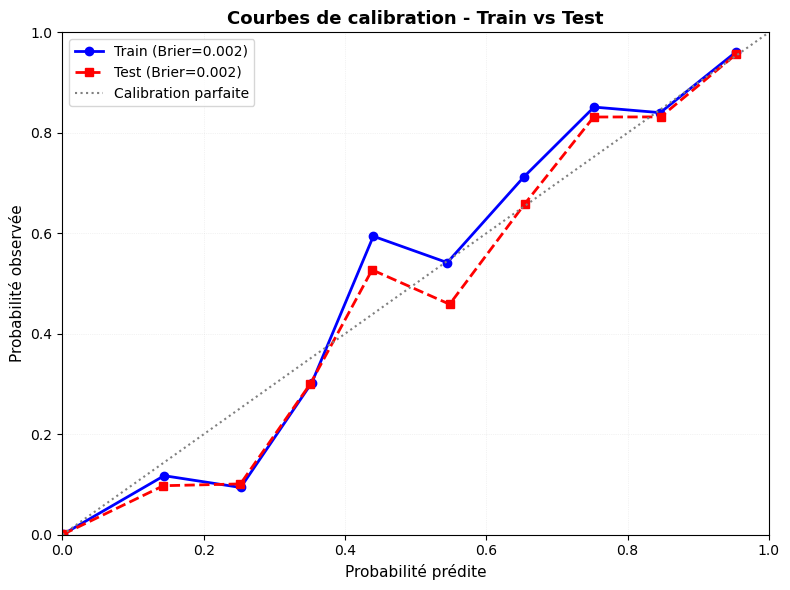


RÉSULTATS DE CALIBRATION
Brier Score Train : 0.0022
Brier Score Test  : 0.0020
Écart Brier       : 0.0002

ECE Train         : 0.0564
ECE Test          : 0.0527

---------------------------------------------
INTERPRÉTATION :
✓ Excellente calibration (Brier < 0.1)
⚠️  Erreur de calibration modérée (ECE < 0.1)


In [26]:
graphique_courbe_calibration(
    y_train, train_proba,
    y_test, test_proba
)

# Note explicative du Notebook

**Construction du modèle de détection de fraude**

---

## Objectif

Cette étape consiste à développer le modèle de détection de fraude à partir des données préparées lors des phases précédentes (feature engineering et EDA).

L’objectif n’est pas uniquement prédictif. Il s’agit de construire un modèle :  
- Stable  
- Bien calibré  
- Optimisé économiquement  
- Testé hors échantillon  

Le cadre est volontairement opérationnel.

---

## Stratégie de découpage

Le découpage repose sur une **logique temporelle** :  

- **2019** : apprentissage et validation  
- **2020** : test final  

Sur les données 2019 :  
- 80 % pour l’entraînement  
- 20 % pour la validation (recherche du seuil optimal)  

Une **stratification** est appliquée en raison du **déséquilibre extrême** des classes (~0,05 % de fraude).

---

## Hypothèse économique

Le modèle est optimisé selon une logique de coût :  

| Type d’erreur   | Coût (€) |
|------------------|:--------:|
| Faux positif     | 25       |
| Faux négatif     | 125      |

Le coût d’une fraude non détectée est **cinq fois supérieur** à celui d’une fausse alerte.

Le seuil de décision est choisi pour minimiser :  

**Coût total = 25 × Nombre de faux positifs + 125 × Nombre de faux négatifs**

L’objectif est de trouver **un compromis économique** et non un simple maximum de performance statistique.

---

## Architecture du pipeline

Le pipeline est construit avec **scikit-learn** et regroupe toutes les étapes de **transformation et modélisation**.

### Étapes principales

#### Encodage
- Les variables catégorielles sont converties en texte, puis encodées via `OneHotEncoder` avec gestion des modalités inconnues.

#### Isolation Forest
- Un score d’anomalie `if_score` est calculé à partir d’un modèle **Isolation Forest** appliqué sur l’ensemble des variables.  
- Cette variable apporte une dimension non supervisée permettant de mesurer le caractère atypique d’une transaction.

#### Standardisation
- Les variables numériques, y compris `if_score`, sont standardisées via `StandardScaler`.

#### Modélisation — XGBoost
Le modèle retenu est **XGBoost** pour les raisons suivantes :  
- Capacité à modéliser des relations non linéaires complexes  
- Gestion naturelle des interactions entre variables  
- Robustesse face aux valeurs extrêmes  
- Excellentes performances sur données tabulaires  

Le paramètre `scale_pos_weight` est ajusté pour compenser le déséquilibre des classes.

---

## Tuning des hyperparamètres

La recherche des hyperparamètres est effectuée via **RandomizedSearchCV**.  
Le critère retenu est le **Brier Score (neg_brier_score)**.

Ce choix est stratégique :  
- Le XGBoost peut produire des probabilités mal calibrées.  
- Un bon Brier Score indique des probabilités cohérentes.  
- Il limite indirectement le surapprentissage.  

L’objectif est la **stabilité** et la **fiabilité probabiliste**.

---

## Calibration des probabilités

Même après tuning, les probabilités peuvent rester imparfaites.  
Une **calibration isotonic** est appliquée via `CalibratedClassifierCV`.

Cette étape améliore la cohérence des probabilités, ce qui est essentiel lorsque la décision finale repose sur un **seuil économique**.

---

## Optimisation du seuil

Le seuil de classification n’est pas fixé arbitrairement à 0,5.  
Un **optimiseur de coût** est utilisé sur l’échantillon de validation pour identifier le seuil minimisant le coût total.

**Seuil optimal retenu : 0,307**

---

## Performances obtenues  
*(après retrait de `mois_transaction` et `jour_transaction`)*

| Indicateur              | Valeur     |
|-------------------------|------------|
| Coût minimal            | 171 150 €  |
| Rappel                  | 76,9 %     |
| Fraud Loss Rate         | 23,1 %     |
| Alerte Rate             | 0,55 %     |
| False Positive Rate     | 0,188 %    |
| Précision               | 66,3 %     |
| Ratio FP / VP           | 0,51       |

Le modèle détecte **environ 77 % des fraudes** tout en **réduisant le volume d’alertes injustifiées**.

---

## Interprétation

La suppression de `mois_transaction` et `jour_transaction` a permis :  

- Une légère réduction du recall  
- Une amélioration de la précision  
- Une diminution du taux de faux positifs  
- Une meilleure stabilité hors échantillon  
- Une réduction du coût total  

Le modèle devient **plus conservateur**, mais **économiquement plus efficace**.

---

## Conclusion

Le pipeline Machine Learning :  

- Intègre transformation, modélisation et calibration  
- Optimise explicitement un critère économique  
- Généralise correctement sur l’année 2020  
- Présente une meilleure stabilité et un **coût total réduit**  

Il constitue une **solution réaliste et structurée** pour un système opérationnel de détection de fraude, avec un **compromis coût/performance mieux maîtrisé**.
